# Quantifying perturbation efficacy in pooled CRISPR screens

Guide RNAs can have off-target effects or variable efficacy, so after a pooled CRISPR screen we need to know which cells were effectively perturbed and how strongly.
This tutorial covers two complementary methods for this, both built on a shared per-cell perturbation signature.
[Mixscape](https://doi.org/10.1038/s41588-021-00778-2) classifies each targeted cell as perturbed (KO) or non-perturbed (NP) {cite}`Papalexi2021`.
[Mixscale](https://doi.org/10.1038/s41556-025-01622-z) instead assigns a continuous score that quantifies how strongly each cell responded {cite}`Jiang2025`.
We first compute the perturbation signature, then apply each method in turn.

```{dropdown} Applying mixscape to CRISPRa and CRISPRi data

For CRISPRi and CRISPRa, applying Mixscape is more nuanced but still valid under certain conditions.
Unlike knockouts, these modalities do not introduce permanent genomic alterations, but variability in perturbation efficiency can create functionally unperturbed cells.
Factors such as incomplete transcriptional repression/activation, guide RNA efficiency, chromatin state, or variable effector recruitment (e.g., KRAB for CRISPRi, VP64 for CRISPRa) can lead to heterogeneous and continuous perturbation effects.
If these effects result in a clear separation between perturbed and unperturbed-like transcriptomic states, Mixscape can still be meaningfully applied.
However, careful validation is needed to ensure that the identified unperturbed population reflects true biological variability rather than technical artifacts.
```

## Setup

In [1]:
import muon as mu
import pertpy as pt
import scanpy as sc

mkdir -p failed for path /mpl: [Errno 13] Permission denied: '/mpl'


Matplotlib created a temporary cache directory at /tmp/matplotlib-rbue5acm because there was an issue with the default path (/mpl); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


/home/lheumos/miniforge3/envs/pertpy/lib/python3.14/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Dataset

We use the Papalexi ECCITE-seq 111 gRNA ECCITE-seq dataset which was generated from stimulated THP-1 cells.

In [2]:
mdata = pt.dt.papalexi_2021()
gene_target_data = mdata.obs["gene_target"].copy()
mdata.push_obs(columns=["replicate", "phase", "perturbation", "NT"], mods=["rna"])
mdata["rna"].obs["gene_target"] = gene_target_data
mdata["adt"].obs["gene_target"] = gene_target_data
mdata

/home/lheumos/miniforge3/envs/pertpy/lib/python3.14/site-packages/mudata/_core/mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


MuData object with n_obs × n_vars = 20729 × 18776
  obs:	'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'phase'
  var:	'name'
  4 modalities
    rna:	20729 × 18649
      obs:	'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'NT', 'perturbation', 'phase', 'replicate', 'gene_target'
      var:	'name'
    adt:	20729 × 4
      obs:	'nCount_ADT', 'nFeature_ADT', 'gene_target'
      var:	'name'
    hto:	20729 × 12
      obs:	'nCount_HTO', 'nFeature_HTO', 'technique'
      var:	'name'
    gdo:	20729 × 111
      obs:	'nCount_GDO'
      var:	'name'

## Preprocessing

We preprocess both RNA and proteins according to the standard pipelines.

### RNA

In [3]:
mdata["rna"]

AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'NT', 'perturbation', 'phase', 'replicate', 'gene_target'
    var: 'name'

In [4]:
sc.pp.normalize_total(mdata["rna"])

In [5]:
sc.pp.log1p(mdata["rna"])

In [6]:
sc.pp.highly_variable_genes(mdata["rna"], subset=True)

### Protein

In [7]:
mdata["adt"]

AnnData object with n_obs × n_vars = 20729 × 4
    obs: 'nCount_ADT', 'nFeature_ADT', 'gene_target'
    var: 'name'

In [8]:
# Normalize across cells (axis=1)
mu.prot.pp.clr(mdata["adt"], axis=1)

/home/lheumos/miniforge3/envs/pertpy/lib/python3.14/site-packages/muon/_prot/preproc.py:222: UserWarning: adata.X is sparse but not in CSR format. Converting to CSR.
  warn("adata.X is sparse but not in CSR format. Converting to CSR.")


## RNA-based clustering is driven by confounding sources of variation

Using the common gene expression-based cell clustering workflow, we expect to discern clusters unique to specific perturbations.
Contrary to this, clustering is mainly influenced by cell cycle phases and replicate IDs.
The exception is a single cluster, characterized by cells expressing gRNAs related to the IFNgamma pathway.

```{dropdown} Assumptions when calculating perturbation signatures

When calculating the perturbation-specific signatures, mixscape makes strong assumptions such as cells with a perturbation not exhibiting compositional differences with respect to variation seen within the control cells. Additional limitations include the assumption that perturbation effects are additive and separable from underlying cell state, the equal weighting of all genes regardless of their relevance to the perturbation target, and the failure to account for temporal dynamics in cellular responses where early and late responding genes create composite signatures.
```

In [9]:
sc.pp.pca(mdata["rna"])

In [10]:
sc.pp.neighbors(mdata["rna"], metric="cosine")

In [11]:
sc.tl.umap(mdata["rna"])

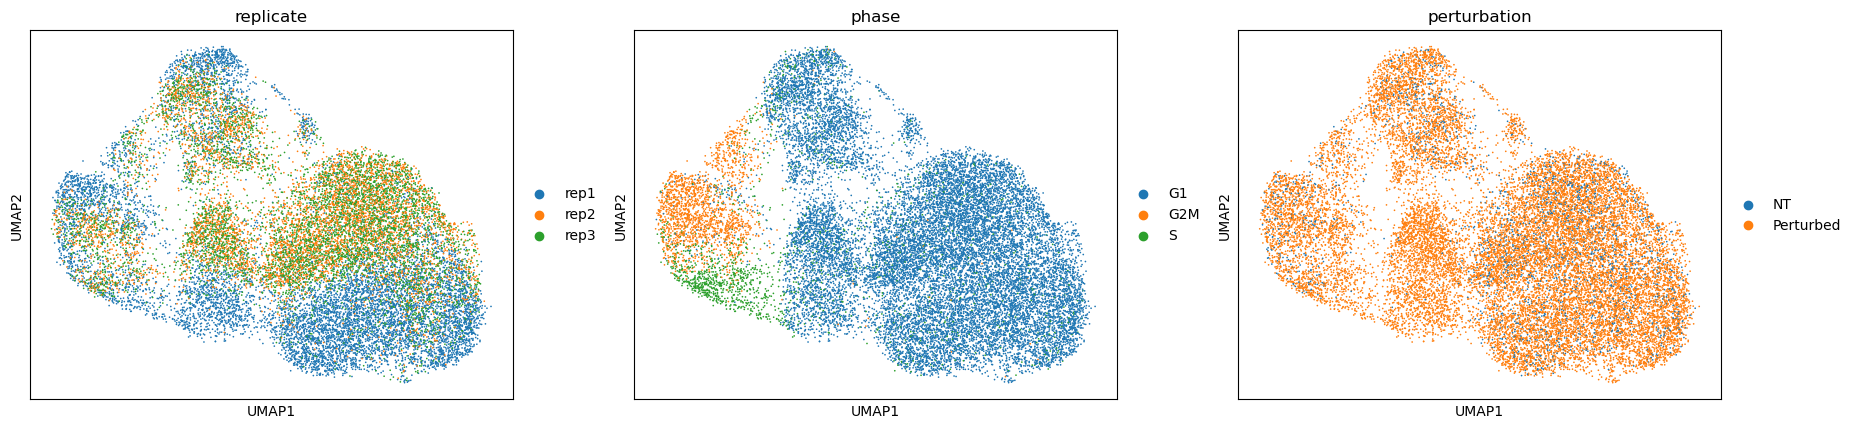

In [12]:
sc.pl.umap(mdata["rna"], color=["replicate", "phase", "perturbation"])

## Calculating local perturbation signatures mitigates confounding effects

To regress out the confounding effects, we calculate local perturbation signatures.
For each cell, we identify `n_neighbors` cells from the control pool with the most similar mRNA expression profiles.
The perturbation signature is calculated by subtracting the averaged mRNA expression profile of the control neighbors from the mRNA expression profile of each cell.

In [13]:
ms = pt.tl.Mixscape()
ms.perturbation_signature(mdata["rna"], pert_key="perturbation", control="NT", split_by="replicate")

In [14]:
adata_pert = mdata["rna"].copy()

In [15]:
adata_pert.X = adata_pert.layers["X_pert"]

In [16]:
sc.pp.pca(adata_pert)

In [17]:
sc.pp.neighbors(adata_pert, metric="cosine")

In [18]:
sc.tl.umap(adata_pert)

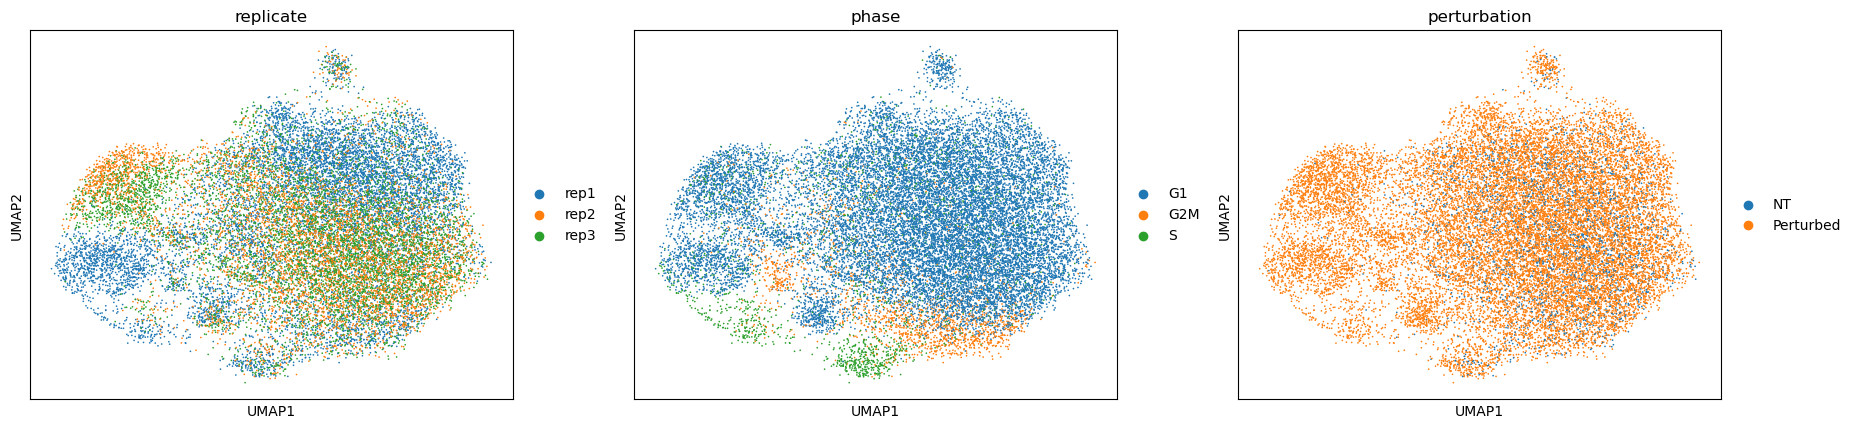

In [19]:
sc.pl.umap(adata_pert, color=["replicate", "phase", "perturbation"])

## Mixscape: classifying perturbed cells

Mixscape assigns each targeted cell a binary label, perturbed (KO) or non-perturbed (NP), by modelling the perturbation signature as a mixture of the non-targeting control distribution and a perturbed distribution.

### Mixscape identifies cells with no detectable perturbation

mixscape models each target gene class as a combination of two Gaussian distributions: one for knockout (KO) cells and another for non-perturbed (NP) cells.
We assume that NP cells exhibit the same distribution as cells with non-targeting gRNAs (NT).
We estimate the KO cell distribution and then compute the posterior probability of a cell belonging to the KO group.
Cells with a probability above 0.5 are classified as KOs.
This method helped us identify KOs in 11 target gene classes, revealing variations in gRNA targeting efficiency across these classes.

In [20]:
ms.mixscape(adata=mdata["rna"], control="NT", pert_key="gene_target", layer="X_pert")

We detect variation in gRNA targeting efficiency within each class.

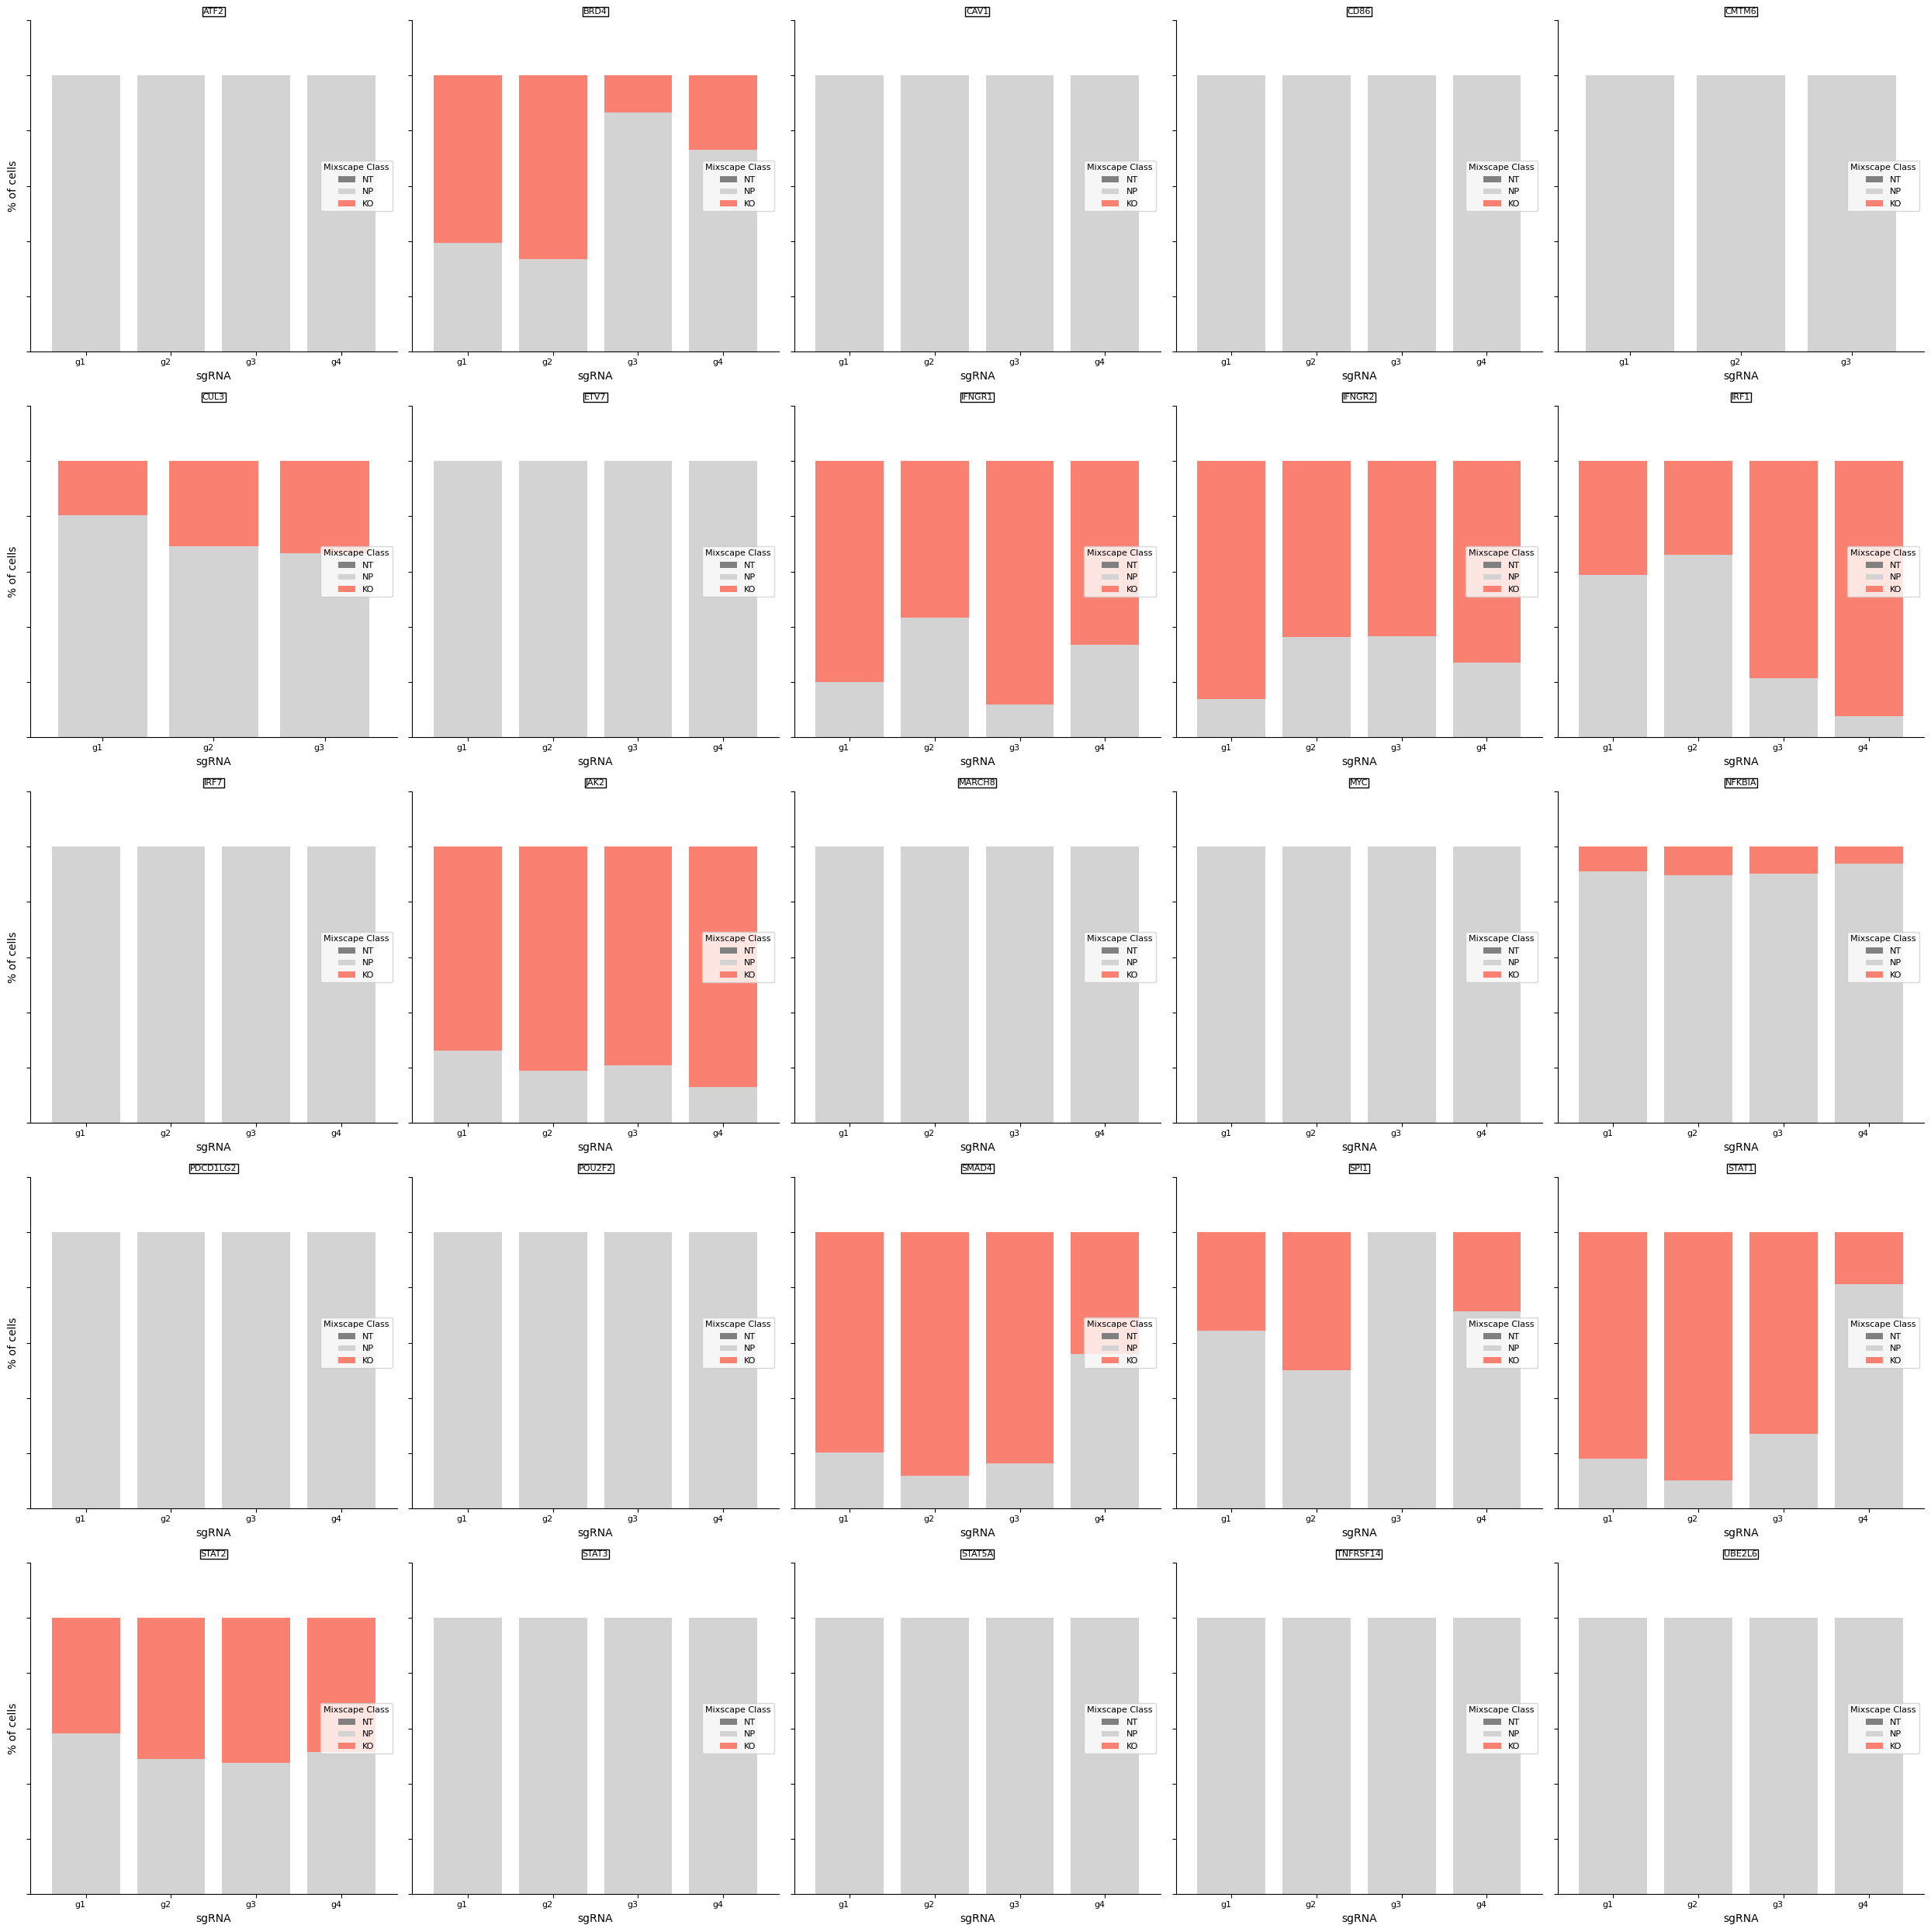

In [21]:
ms.plot_barplot(mdata["rna"], guide_rna_column="NT")

### Inspecting mixscape results

To validate that mixscape accurately assigns perturbation status, we can examine the perturbation score distributions and the posterior probabilities of cells in a specific target gene class, like IFNGR2, comparing these with non-targeting (NT) cells.
Additionally, we can conduct differential expression (DE) analyses, demonstrating that reduced expression of IFNG-pathway genes is unique to IFNGR2 KO cells.
As an independent verification, we can also assess the PD-L1 protein expression levels in non-perturbed (NP) and knockout (KO) cells for genes known to regulate PD-L1.


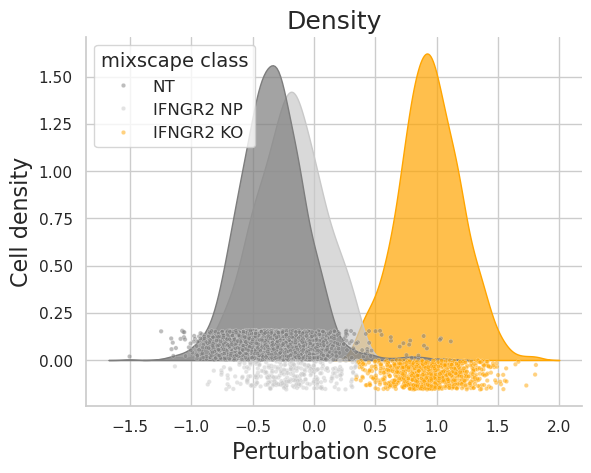

In [22]:
ms.plot_perturbscore(adata=mdata["rna"], pert_key="gene_target", target_gene="IFNGR2", color="orange")

Inspect the posterior probability values in NP and KO cells.

/home/lheumos/miniforge3/envs/pertpy/lib/python3.14/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/lheumos/miniforge3/envs/pertpy/lib/python3.14/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/lheumos/code/pertpy/pertpy/tools/_perturbation_screen/_mixscape.py:872: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.stripplot(  # noqa: PLW2901


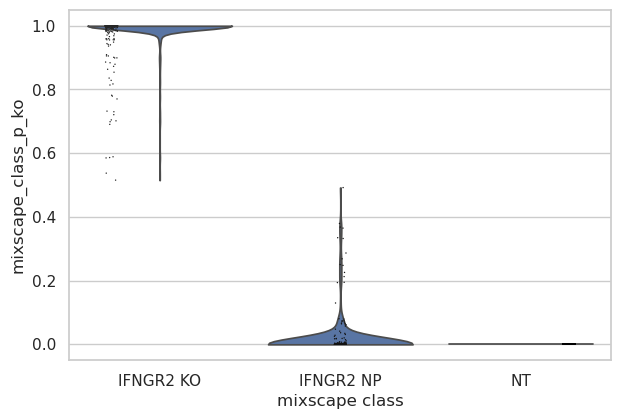

In [23]:
ms.plot_violin(
    adata=mdata["rna"],
    target_gene_idents=["NT", "IFNGR2 NP", "IFNGR2 KO"],
    groupby="mixscape_class",
)

Run DE analysis and visualize results on a heatmap ordering cells by their posterior probability values.

categories: IFNGR2 KO, IFNGR2 NP, NT
var_group_labels: NT


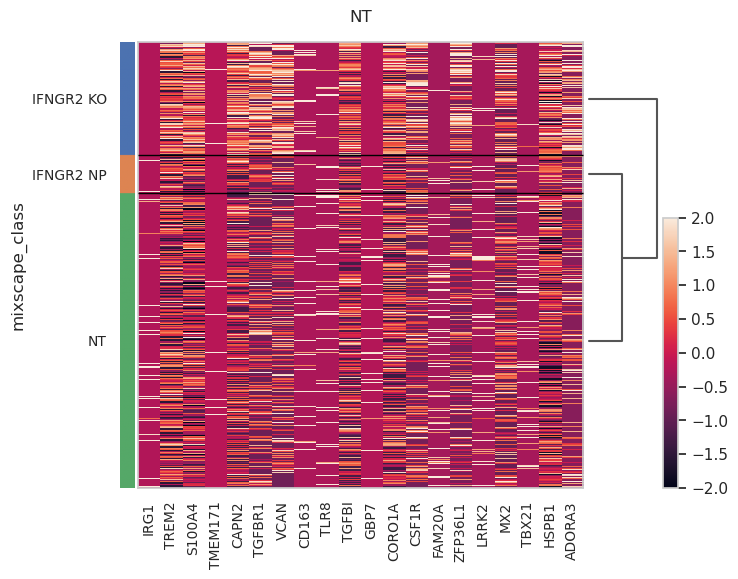

In [24]:
ms.plot_heatmap(
    adata=mdata["rna"],
    pert_key="gene_target",
    target_gene="IFNGR2",
    layer="X_pert",
    control="NT",
)

Show that only IFNG pathway KO cells have a reduction in PD-L1 protein expression.

/home/lheumos/miniforge3/envs/pertpy/lib/python3.14/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


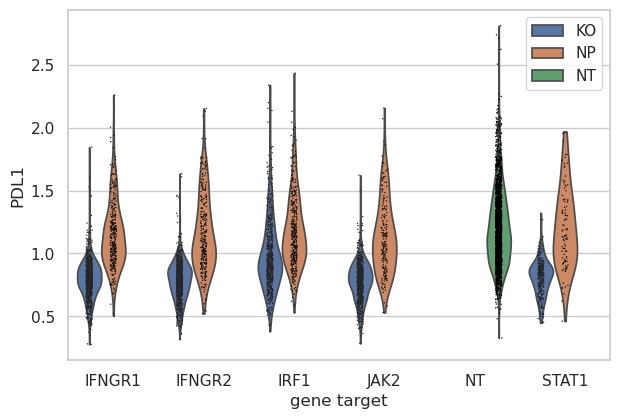

In [25]:
mdata["adt"].obs["mixscape_class_global"] = mdata["rna"].obs["mixscape_class_global"]
ms.plot_violin(
    adata=mdata["adt"],
    target_gene_idents=["NT", "JAK2", "STAT1", "IFNGR1", "IFNGR2", "IRF1"],
    keys="PDL1",
    groupby="gene_target",
    hue="mixscape_class_global",
)

### Visualizing perturbation responses with Linear Discriminant Analysis (LDA)

Finally, we use LDA as a dimensionality reduction method to visualize perturbation-specific clusters.
LDA tries to maximize the separability of known labels (mixscape classes) using both gene expression and the labels as input.

In [26]:
ms = pt.tl.Mixscape()
ms.lda(adata=mdata["rna"], control="NT", pert_key="gene_target", layer="X_pert")

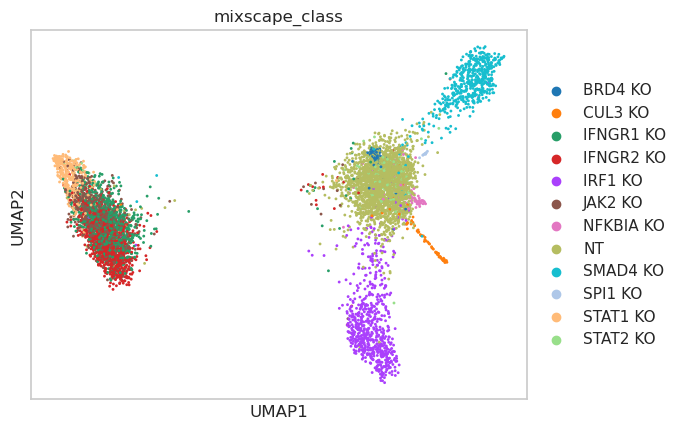

In [27]:
ms.plot_lda(adata=mdata["rna"], control="NT")

## Mixscale: scoring perturbation strength

While Mixscape gives a binary call, many screens, especially CRISPRi and CRISPRa, produce a gradient of perturbation strengths rather than a clean on/off effect.
[Mixscale](https://doi.org/10.1038/s41556-025-01622-z) instead assigns a continuous per-cell perturbation score {cite}`Jiang2025`.
The score is the projection of each cell's perturbation signature onto the perturbation direction vector, standardized against the non-targeting control cells.
It reuses the same perturbation signature and differential expression steps, so we can run it directly on the object we already prepared.

In [28]:
msc = pt.tl.Mixscale()
msc.mixscale(mdata["rna"], "gene_target", "NT", layer="X_pert")
mdata["rna"].obs[["gene_target", "mixscape_class_global", "mixscale_score"]].head()

,gene_target,mixscape_class_global,mixscale_score
index,,,
l1_AAACCTGAGCCAGAAC,STAT2,KO,4.455721
l1_AAACCTGAGTGGACGT,CAV1,NP,1.000000
l1_AAACCTGCATGAGCGA,STAT1,KO,5.582020
l1_AAACCTGTCTTGTCAT,CD86,NP,1.000000
l1_AAACGGGAGAACAACT,IRF7,NP,1.000000


Non-targeting control cells receive a score of zero by construction.
Grouping the cells by their Mixscape call shows that the continuous score recovers the binary classification: the cells labelled KO score far higher than the non-perturbed (NP) and non-targeting (NT) cells.

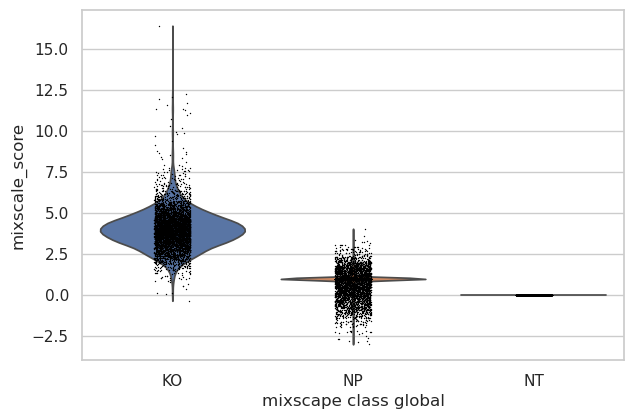

In [29]:
sc.pl.violin(mdata["rna"], keys="mixscale_score", groupby="mixscape_class_global")

The score additionally resolves heterogeneity that the binary call collapses.
Focusing on IFNGR2, the non-targeting controls sit at zero and the NP cells stay low, while the KO cells span a broad range of response strengths rather than a single value.

<Axes: xlabel='mixscape_class', ylabel='mixscale_score'>

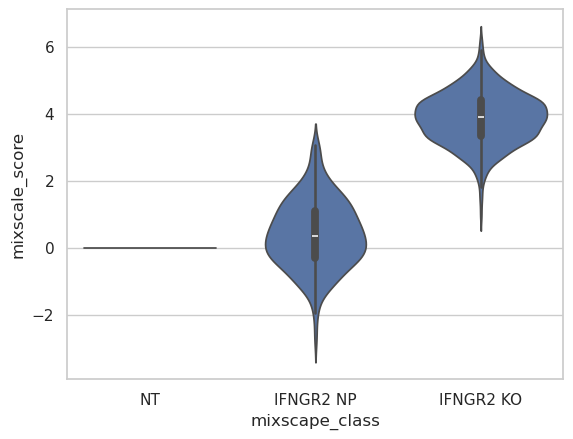

In [30]:
import seaborn as sns

obs = mdata["rna"].obs
ifngr2 = obs[obs["mixscape_class"].isin(["NT", "IFNGR2 NP", "IFNGR2 KO"])]
sns.violinplot(data=ifngr2, x="mixscape_class", y="mixscale_score", order=["NT", "IFNGR2 NP", "IFNGR2 KO"])

Projected onto the perturbation-signature embedding, the score reveals a continuous gradient of response strength where Mixscape draws a hard perturbed/non-perturbed boundary.

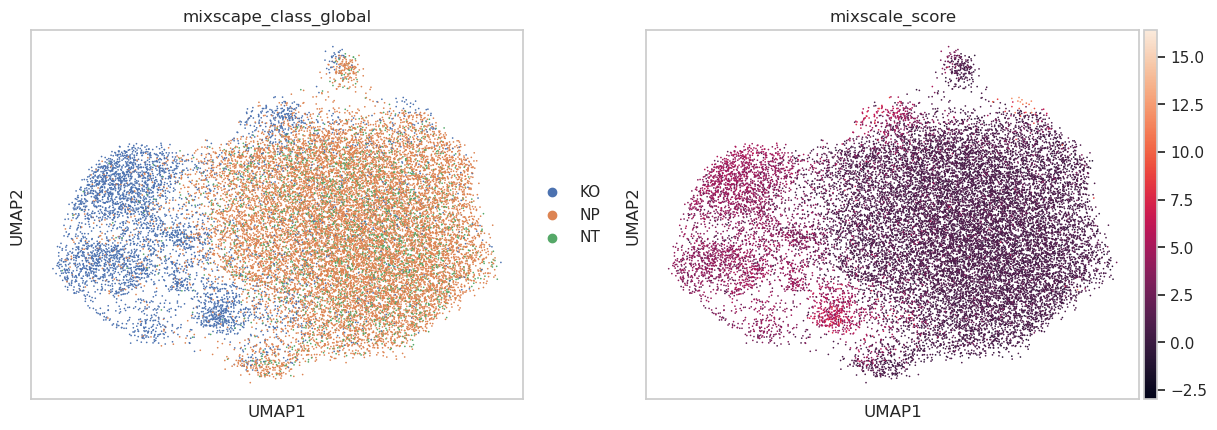

In [31]:
adata_pert.obs["mixscape_class_global"] = mdata["rna"].obs["mixscape_class_global"]
adata_pert.obs["mixscale_score"] = mdata["rna"].obs["mixscale_score"]
sc.pl.umap(adata_pert, color=["mixscape_class_global", "mixscale_score"])

Aggregated per target gene, the score summarises how strongly each perturbation acted across the cells that received it.
The non-targeting controls remain at zero, while the spread of each target gene exposes the variation in perturbation efficacy between genes.

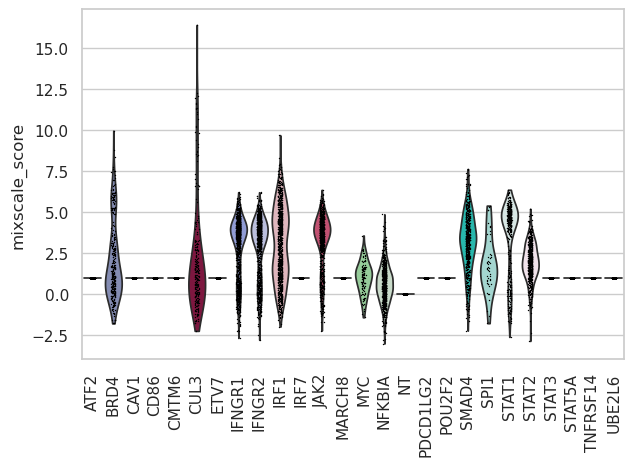

In [32]:
sc.pl.violin(mdata["rna"], keys="mixscale_score", groupby="gene_target", rotation=90)